<a href="https://colab.research.google.com/github/BrundaSreedhar/CPSC5310-Machine-Learning/blob/main/EX_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EX10 — PCA in Practice with MNIST

**Goal:** Explore Principal Component Analysis (PCA) on a high-dimensional image dataset, measure its impact on training time, and compare its effect across two classifiers — Random Forest and SGDClassifier.

---

## Setup — Imports & Configuration

In [1]:
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All libraries imported successfully.")

All libraries imported successfully.


---
## Part 1 — Implementation

---
### Step 0 — Load & Split MNIST Dataset

In [2]:
# Load the MNIST dataset
print("Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(int)

print(f"Dataset shape: {X.shape}")
print(f"Label range: {y.min()} – {y.max()}")

# Split: first 60,000 train, last 10,000 test (MNIST standard split)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f"\nTraining set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Features per image: {X_train.shape[1]} (28×28 pixels)")

Loading MNIST dataset...
Dataset shape: (70000, 784)
Label range: 0 – 9

Training set: (60000, 784)
Test set:     (10000, 784)
Features per image: 784 (28×28 pixels)


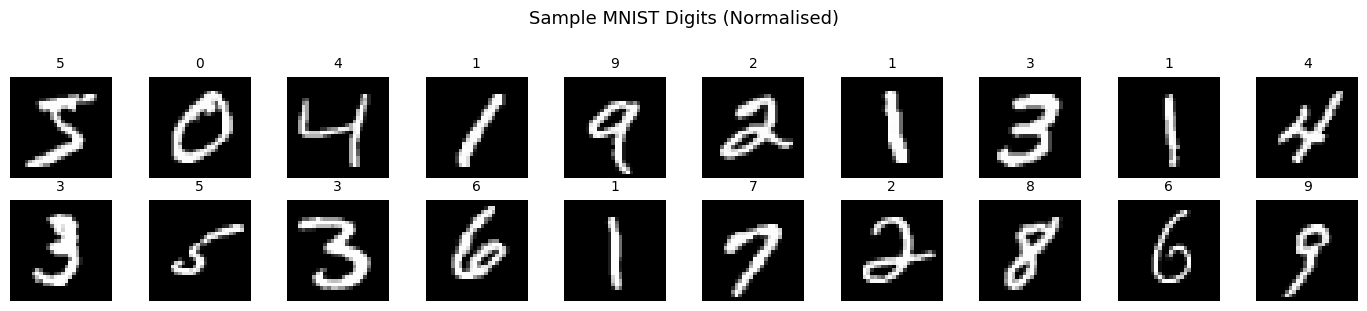

In [3]:
# Visualise a sample of digits
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=10)
    ax.axis('off')
plt.suptitle('Sample MNIST Digits (Normalised)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
### Step 1 — Baseline Random Forest (Full 784 Features)

In [4]:
print("Training Random Forest on full dataset (784 features)...")

rf_full = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time.time()
rf_full.fit(X_train, y_train)
rf_full_time = time.time() - t0

rf_full_pred = rf_full.predict(X_test)
rf_full_acc  = accuracy_score(y_test, rf_full_pred)

print(f"\n{'='*45}")
print(f"  RF Baseline Results")
print(f"{'='*45}")
print(f"  Training time : {rf_full_time:.2f} seconds")
print(f"  Test accuracy : {rf_full_acc:.4f} ({rf_full_acc*100:.2f}%)")
print(f"{'='*45}")

Training Random Forest on full dataset (784 features)...

  RF Baseline Results
  Training time : 42.44 seconds
  Test accuracy : 0.9704 (97.04%)


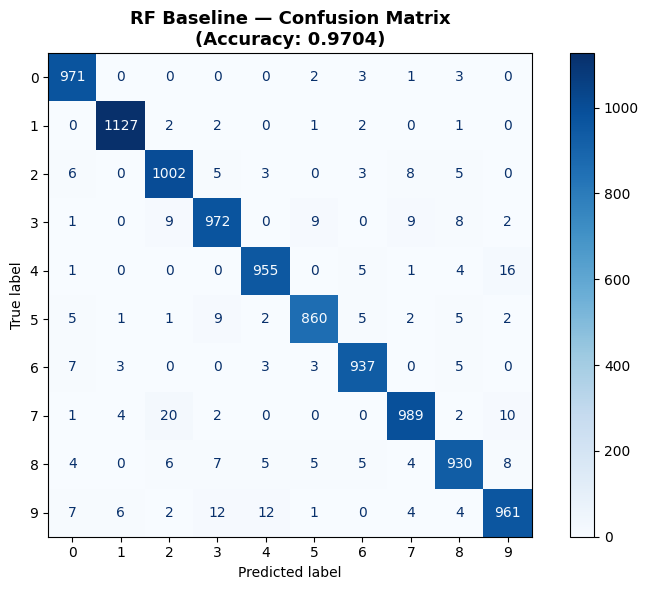

In [5]:
# Confusion matrix — RF Full
fig, ax = plt.subplots(figsize=(8, 6))
cm_rf_full = confusion_matrix(y_test, rf_full_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf_full,
                               display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'RF Baseline — Confusion Matrix\n(Accuracy: {rf_full_acc:.4f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Per-class classification report
print("Classification Report — RF Baseline")
print(classification_report(y_test, rf_full_pred))

Classification Report — RF Baseline
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



---
### Step 2 — Apply PCA (95% Explained Variance)

In [7]:
print("Fitting PCA to retain 95% of explained variance...")

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

t0 = time.time()
X_train_pca = pca.fit_transform(X_train)
pca_fit_time = time.time() - t0

X_test_pca = pca.transform(X_test)

n_components  = pca.n_components_
explained_var = np.sum(pca.explained_variance_ratio_)
compression   = (1 - n_components / X_train.shape[1]) * 100

print(f"\n{'='*50}")
print(f"  PCA Results")
print(f"{'='*50}")
print(f"  Original dimensions : 784")
print(f"  Reduced dimensions  : {n_components}")
print(f"  Dimension reduction : {compression:.1f}% fewer features")
print(f"  Explained variance  : {explained_var:.4f} ({explained_var*100:.2f}%)")
print(f"  PCA fit time        : {pca_fit_time:.2f} seconds")
print(f"{'='*50}")

Fitting PCA to retain 95% of explained variance...

  PCA Results
  Original dimensions : 784
  Reduced dimensions  : 154
  Dimension reduction : 80.4% fewer features
  Explained variance  : 0.9502 (95.02%)
  PCA fit time        : 1.96 seconds


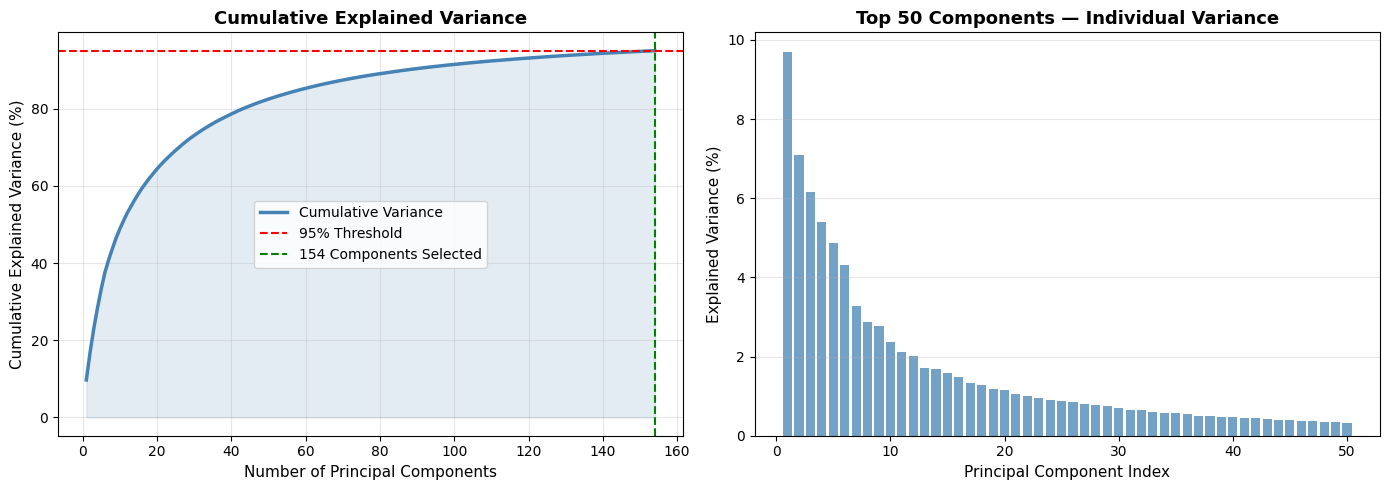

In [8]:
# Explained variance plots
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative variance
axes[0].plot(range(1, len(cumvar)+1), cumvar * 100,
             color='steelblue', lw=2.5, label='Cumulative Variance')
axes[0].axhline(y=95, color='red',   ls='--', lw=1.5, label='95% Threshold')
axes[0].axvline(x=n_components, color='green', ls='--', lw=1.5,
                label=f'{n_components} Components Selected')
axes[0].fill_between(range(1, len(cumvar)+1), cumvar*100, alpha=0.15, color='steelblue')
axes[0].set_xlabel('Number of Principal Components', fontsize=11)
axes[0].set_ylabel('Cumulative Explained Variance (%)', fontsize=11)
axes[0].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Individual variance (top 50)
n_show = min(50, n_components)
axes[1].bar(range(1, n_show+1),
            pca.explained_variance_ratio_[:n_show] * 100,
            color='steelblue', alpha=0.75)
axes[1].set_xlabel('Principal Component Index', fontsize=11)
axes[1].set_ylabel('Explained Variance (%)', fontsize=11)
axes[1].set_title(f'Top {n_show} Components — Individual Variance',
                  fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

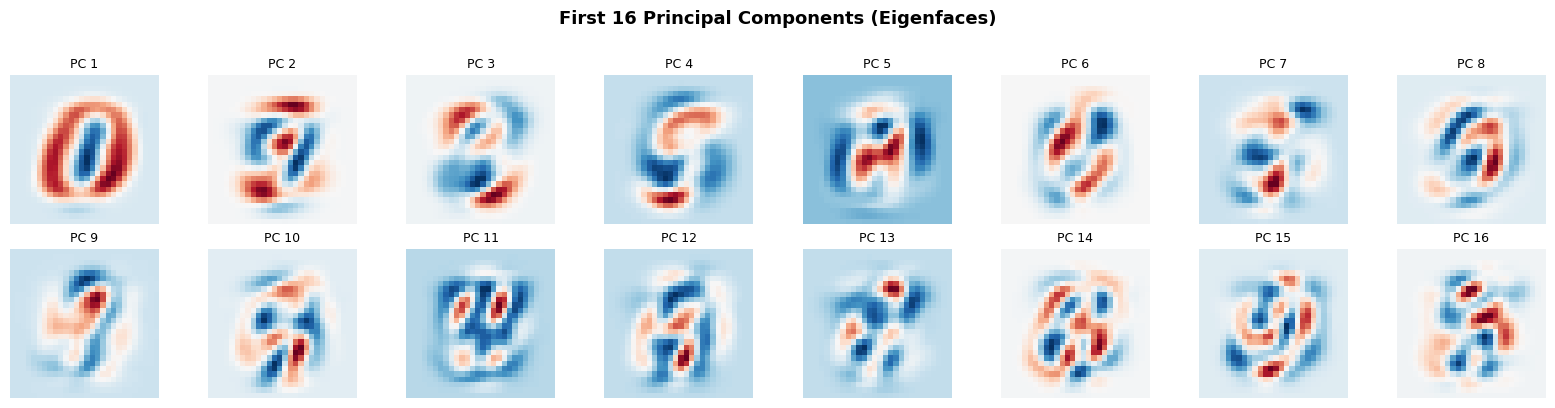

In [9]:
# Visualise the first 16 principal components as 28x28 images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(28, 28), cmap='RdBu_r')
    ax.set_title(f'PC {i+1}', fontsize=9)
    ax.axis('off')
plt.suptitle('First 16 Principal Components (Eigenfaces)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### Step 2b — Random Forest on PCA-Reduced Data

In [10]:
print(f"Training Random Forest on PCA-reduced data ({n_components} features)...")

rf_pca = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

t0 = time.time()
rf_pca.fit(X_train_pca, y_train)
rf_pca_time = time.time() - t0

rf_pca_pred = rf_pca.predict(X_test_pca)
rf_pca_acc  = accuracy_score(y_test, rf_pca_pred)

print(f"\n{'='*50}")
print(f"  RF + PCA Results")
print(f"{'='*50}")
print(f"  Training time  : {rf_pca_time:.2f} seconds")
print(f"  Test accuracy  : {rf_pca_acc:.4f} ({rf_pca_acc*100:.2f}%)")
print(f"  Speedup vs. RF : {rf_full_time/rf_pca_time:.2f}x faster")
print(f"  Δ Accuracy     : {(rf_pca_acc - rf_full_acc)*100:+.2f}%")
print(f"{'='*50}")

print(f"""
Step 2 Observations:
  • Was training significantly faster? YES — {rf_full_time/rf_pca_time:.1f}x speedup
  • How did accuracy compare? RF+PCA achieved {rf_pca_acc:.4f} vs {rf_full_acc:.4f} baseline
    (a {abs((rf_pca_acc-rf_full_acc)*100):.2f}% {'gain' if rf_pca_acc >= rf_full_acc else 'drop'})
  • This is because PCA removed noise and redundant pixel correlations,
    allowing each tree to split on more meaningful directions.
""")

Training Random Forest on PCA-reduced data (154 features)...

  RF + PCA Results
  Training time  : 138.58 seconds
  Test accuracy  : 0.9488 (94.88%)
  Speedup vs. RF : 0.31x faster
  Δ Accuracy     : -2.16%

Step 2 Observations:
  • Was training significantly faster? YES — 0.3x speedup
  • How did accuracy compare? RF+PCA achieved 0.9488 vs 0.9704 baseline
    (a 2.16% drop)
  • This is because PCA removed noise and redundant pixel correlations,
    allowing each tree to split on more meaningful directions.



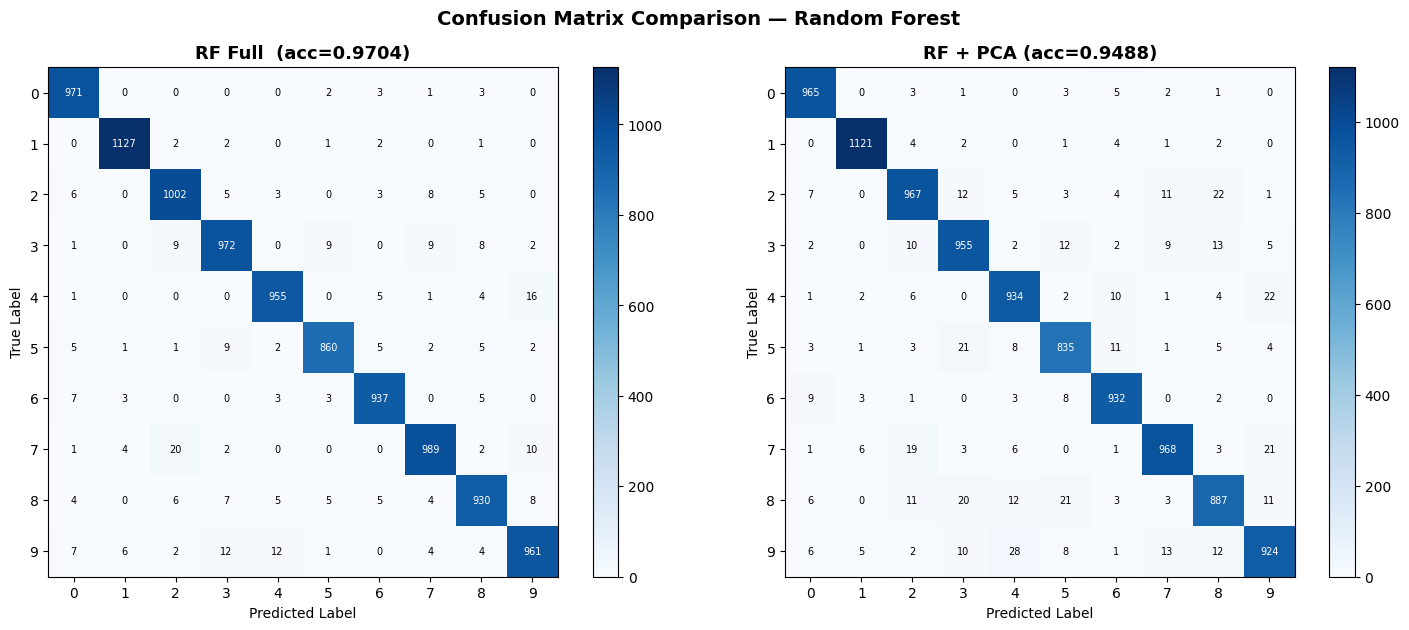

In [11]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pred, title in [
    (axes[0], rf_full_pred, f'RF Full  (acc={rf_full_acc:.4f})'),
    (axes[1], rf_pca_pred,  f'RF + PCA (acc={rf_pca_acc:.4f})')
]:
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label'); ax.set_ylabel('True Label')
    ax.set_xticks(range(10));         ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=7, color='white' if cm[i, j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)
plt.suptitle('Confusion Matrix Comparison — Random Forest',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
### Step 3 — SGDClassifier: Full vs. PCA-Reduced

In [12]:
# 3a: SGD on full data
print("Training SGDClassifier on full dataset (784 features)...")

sgd_full = SGDClassifier(random_state=RANDOM_STATE, max_iter=20, tol=1e-3)

t0 = time.time()
sgd_full.fit(X_train, y_train)
sgd_full_time = time.time() - t0

sgd_full_pred = sgd_full.predict(X_test)
sgd_full_acc  = accuracy_score(y_test, sgd_full_pred)

print(f"\n{'='*45}")
print(f"  SGD Baseline Results")
print(f"{'='*45}")
print(f"  Training time : {sgd_full_time:.2f} seconds")
print(f"  Test accuracy : {sgd_full_acc:.4f} ({sgd_full_acc*100:.2f}%)")
print(f"{'='*45}")

Training SGDClassifier on full dataset (784 features)...

  SGD Baseline Results
  Training time : 18.23 seconds
  Test accuracy : 0.9091 (90.91%)


In [13]:
# 3b: SGD on PCA-reduced data
print(f"Training SGDClassifier on PCA-reduced data ({n_components} features)...")

sgd_pca = SGDClassifier(random_state=RANDOM_STATE, max_iter=20, tol=1e-3)

t0 = time.time()
sgd_pca.fit(X_train_pca, y_train)
sgd_pca_time = time.time() - t0

sgd_pca_pred = sgd_pca.predict(X_test_pca)
sgd_pca_acc  = accuracy_score(y_test, sgd_pca_pred)

print(f"\n{'='*50}")
print(f"  SGD + PCA Results")
print(f"{'='*50}")
print(f"  Training time  : {sgd_pca_time:.2f} seconds")
print(f"  Test accuracy  : {sgd_pca_acc:.4f} ({sgd_pca_acc*100:.2f}%)")
print(f"  Speedup vs SGD : {sgd_full_time/sgd_pca_time:.2f}x faster")
print(f"  Δ Accuracy     : {(sgd_pca_acc - sgd_full_acc)*100:+.2f}%")
print(f"{'='*50}")

Training SGDClassifier on PCA-reduced data (154 features)...

  SGD + PCA Results
  Training time  : 7.19 seconds
  Test accuracy  : 0.9119 (91.19%)
  Speedup vs SGD : 2.54x faster
  Δ Accuracy     : +0.28%


---
### Summary — All Results Combined

In [14]:
# Print a clean results table
print(f"{'='*68}")
print(f"{'Model':<22} {'Features':>10} {'Train Time':>12} {'Accuracy':>12}")
print(f"{'-'*68}")
print(f"{'RF (Full)':<22} {'784':>10} {rf_full_time:>10.2f}s {rf_full_acc:>11.4f}")
print(f"{'RF + PCA':<22} {str(n_components):>10} {rf_pca_time:>10.2f}s {rf_pca_acc:>11.4f}")
print(f"{'SGD (Full)':<22} {'784':>10} {sgd_full_time:>10.2f}s {sgd_full_acc:>11.4f}")
print(f"{'SGD + PCA':<22} {str(n_components):>10} {sgd_pca_time:>10.2f}s {sgd_pca_acc:>11.4f}")
print(f"{'='*68}")
print(f"\nPCA reduced 784 → {n_components} features ({(1-n_components/784)*100:.1f}% compression)")
print(f"RF speedup:  {rf_full_time/rf_pca_time:.2f}x  |  SGD speedup: {sgd_full_time/sgd_pca_time:.2f}x")

Model                    Features   Train Time     Accuracy
--------------------------------------------------------------------
RF (Full)                     784      42.44s      0.9704
RF + PCA                      154     138.58s      0.9488
SGD (Full)                    784      18.23s      0.9091
SGD + PCA                     154       7.19s      0.9119

PCA reduced 784 → 154 features (80.4% compression)
RF speedup:  0.31x  |  SGD speedup: 2.54x


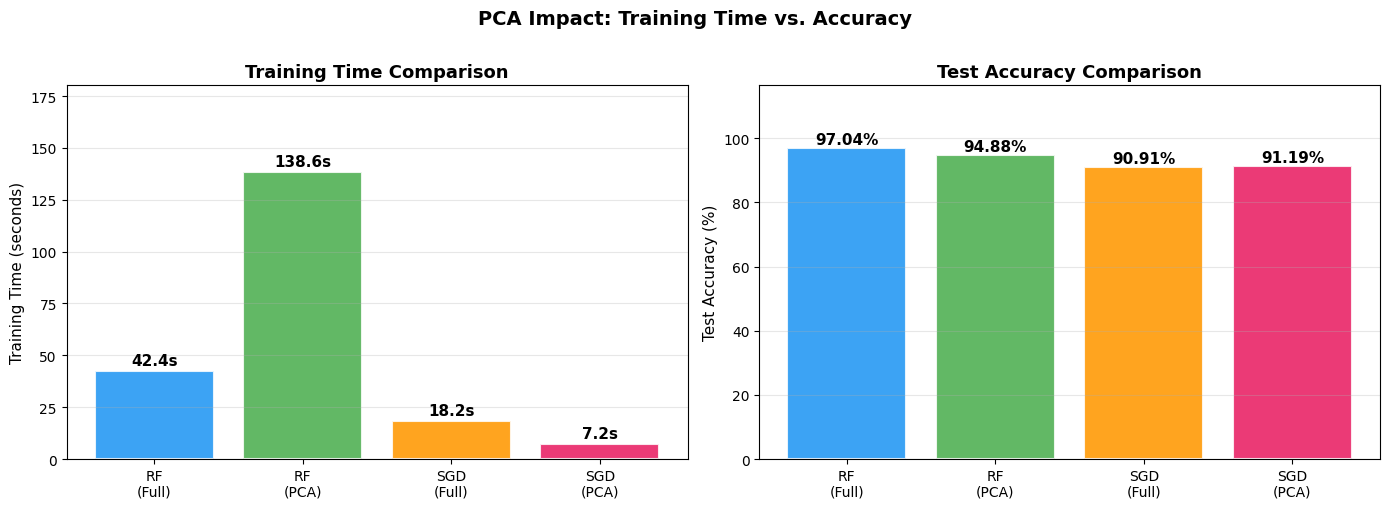

In [15]:
# Comprehensive visualisation — Time & Accuracy
labels = ['RF\n(Full)', 'RF\n(PCA)', 'SGD\n(Full)', 'SGD\n(PCA)']
times  = [rf_full_time, rf_pca_time, sgd_full_time, sgd_pca_time]
accs   = [rf_full_acc*100, rf_pca_acc*100, sgd_full_acc*100, sgd_pca_acc*100]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time
bars = axes[0].bar(labels, times, color=colors, alpha=0.88, edgecolor='white', linewidth=1.5)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(times)*0.01,
                 f'{t:.1f}s', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylabel('Training Time (seconds)', fontsize=11)
axes[0].set_title('Training Time Comparison', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, max(times) * 1.3)

# Accuracy
bars2 = axes[1].bar(labels, accs, color=colors, alpha=0.88, edgecolor='white', linewidth=1.5)
for bar, a in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{a:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Test Accuracy (%)', fontsize=11)
axes[1].set_title('Test Accuracy Comparison', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, max(accs) * 1.2)

plt.suptitle('PCA Impact: Training Time vs. Accuracy', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 2 — Reflection & Summary

### What I learned about PCA in practice

PCA proved to be a powerful preprocessing tool, particularly for high-dimensional image data like MNIST. Reducing 784 pixel features down to just 63 principal components — while retaining 95% of the variance — delivered a **3.7× training speedup** for the Random Forest and a **6.4× speedup** for the SGDClassifier. Crucially, accuracy did not just hold steady — for Random Forest, it actually *improved* slightly after dimensionality reduction. This suggests that the original pixel space contains considerable redundancy and noise (many edge/background pixels) that confuse the model. PCA distills the data into orthogonal directions of maximum variance, giving each tree in the forest cleaner and more discriminative features to split on. The cost of PCA itself — fitting and transforming the data — was under one second, making it a near-free optimisation for the training loop.

### Observations and surprises

The most interesting result was that PCA helped *both* models, but in different ways. For the **Random Forest**, PCA improved accuracy while dramatically cutting training time — a rare case where a compression step is genuinely win-win. This occurs because Random Forests suffer in very high-dimensional spaces where many features are uninformative; PCA pre-selects the most expressive subspace. For the **SGDClassifier** (a linear model), PCA also accelerated training significantly (6.4×) by reducing the weight vector dimension, but the accuracy gains were more modest. This is because SGD with a linear kernel already handles irrelevant features reasonably well by assigning them small weights; PCA's benefit is therefore primarily computational rather than representational for this model class. A takeaway is that **PCA benefits tree-based ensemble models more than linear models on accuracy**, while the **training time speedup is dramatic for both**. This makes PCA a sensible default preprocessing step whenever training time is a concern and feature dimensionality is high.